<a href="https://colab.research.google.com/github/DhairyaDave08/BetaData-SpaceX/blob/main/Notebooks/05_SHAP_explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **05  SHAP Explainability**

Goal: make individual mission-risk predictions interpretable. A risk score
alone isn't enough for an investigator, mission planner, or judge to trust —
they need to know *why* a specific launch was flagged as risky.

This notebook:
1. Loads the final trained model (`models/model.pkl`) and its metadata
   directly from GitHub — no retraining, no recomputation of features.
2. Builds a model-agnostic SHAP explainer (Permutation-based, since our
   final model is a `CalibratedClassifierCV` wrapping a full sklearn
   Pipeline, not a raw tree model that TreeExplainer could use directly).
3. Validates explanations on a handful of real historical launches to
   confirm the attributions make intuitive sense.
4. Produces a global feature-importance summary plot for the presentation deck.
5. Confirms `src/predict.py` and `src/explain.py` work correctly end-to-end —
   this is the exact interface the Streamlit dashboard will call.

This directly satisfies Objective #5 ("per-mission feature attribution using
SHAP") and contributes to Analytics & Visualization Depth (15 pts).

In [1]:
!git clone https://github.com/DhairyaDave08/BetaData-SpaceX.git
%cd BetaData-SpaceX
!pip install -q -r requirements.txt shap

import sys
sys.path.append('/content/BetaData-SpaceX')

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

Cloning into 'BetaData-SpaceX'...
remote: Enumerating objects: 142, done.
remote: Counting objects: 100% (142/142), done.
remote: Compressing objects: 100% (125/125), done.
remote: Total 142 (delta 64), reused 32 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (142/142), 1.76 MiB | 12.04 MiB/s, done.
Resolving deltas: 100% (64/64), done.
/content/BetaData-SpaceX
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 98.9 MB/s eta 0:00:00


## Step 1 — Load the trained model, metadata, and feature set

Everything here is loaded from GitHub as-is — the model is locked, no
retraining happens in this notebook.

In [2]:
from src.predict import load_model, load_metadata, FEATURE_COLS

model = load_model("models/model.pkl")
metadata = load_metadata("models/model_metadata.json")

features_url = "https://raw.githubusercontent.com/DhairyaDave08/BetaData-SpaceX/main/Data/processed/features.csv"
features = pd.read_csv(features_url, parse_dates=["launch_date"])

print("Model loaded successfully.")
print("\nMetadata:")
print(json.dumps(metadata, indent=2))
print(f"\nFeature set shape: {features.shape}")

Model loaded successfully.

Metadata:
{
  "model_type": "RandomForest",
  "calibration": "isotonic"
}

Feature set shape: (4198, 20)


## Step 2 — Sanity check: single prediction

Before building explanations, confirm the model produces a sensible
prediction for a well-known, reliable rocket (Falcon 9, many prior flights,
high historical success rate) — we expect a low risk score here.

In [3]:
from src.predict import predict_single

reliable_example = {
    "rocket_family_grouped": "Falcon 9",
    "launch_site_grouped": "SLC-40",
    "country_grouped": "USA",
    "vehicle_prior_flights": 150,
    "vehicle_prior_success_rate": 0.98,
    "vehicle_age_days": 3600,
    "decade": 2020,
}

result = predict_single(reliable_example, model=model, metadata=metadata)
print(json.dumps(result, indent=2, default=str))

{
  "success_probability": 0.9277,
  "failure_probability": 0.0723,
  "risk_score_0_100": 7.2,
  "risk_band": "Low",
  "predicted_label": "Success",
  "input_used": {
    "rocket_family_grouped": "Falcon 9",
    "launch_site_grouped": "SLC-40",
    "country_grouped": "USA",
    "payload_capacity_kg": 9000,
    "payload_capacity_known": false,
    "vehicle_prior_flights": 150,
    "vehicle_prior_success_rate": 0.98,
    "site_prior_flights": 0,
    "site_prior_success_rate": 0.9,
    "country_prior_flights": 0,
    "country_prior_success_rate": 0.9,
    "vehicle_age_days": 3600,
    "decade": 2020,
    "weather_available": false,
    "wind_speed_max_kmh": NaN,
    "temp_max_c": NaN,
    "precipitation_mm": NaN
  }
}


### Contrast check: a young, unproven rocket

Now test a hypothetical early-generation vehicle with few prior flights and
a weaker historical track record — we expect a meaningfully higher risk
score here, confirming the model responds sensibly to vehicle maturity.

In [4]:
young_vehicle_example = {
    "rocket_family_grouped": "other",
    "launch_site_grouped": "other",
    "country_grouped": "other",
    "vehicle_prior_flights": 2,
    "vehicle_prior_success_rate": 0.50,
    "vehicle_age_days": 60,
    "decade": 2020,
}

result_young = predict_single(young_vehicle_example, model=model, metadata=metadata)
print(json.dumps(result_young, indent=2, default=str))

print(f"\nReliable rocket risk score: {result['risk_score_0_100']}")
print(f"Young/unproven rocket risk score: {result_young['risk_score_0_100']}")
assert result_young['risk_score_0_100'] > result['risk_score_0_100'], \
    "Expected the young vehicle to score riskier — check the model/features if this fails."
print("\nSanity check passed: model correctly ranks the unproven vehicle as riskier.")

{
  "success_probability": 0.7256,
  "failure_probability": 0.2744,
  "risk_score_0_100": 27.4,
  "risk_band": "High",
  "predicted_label": "Failure",
  "input_used": {
    "rocket_family_grouped": "other",
    "launch_site_grouped": "other",
    "country_grouped": "other",
    "payload_capacity_kg": 9000,
    "payload_capacity_known": false,
    "vehicle_prior_flights": 2,
    "vehicle_prior_success_rate": 0.5,
    "site_prior_flights": 0,
    "site_prior_success_rate": 0.9,
    "country_prior_flights": 0,
    "country_prior_success_rate": 0.9,
    "vehicle_age_days": 60,
    "decade": 2020,
    "weather_available": false,
    "wind_speed_max_kmh": NaN,
    "temp_max_c": NaN,
    "precipitation_mm": NaN
  }
}

Reliable rocket risk score: 7.2
Young/unproven rocket risk score: 27.4

Sanity check passed: model correctly ranks the unproven vehicle as riskier.


## Step 3 — Build the SHAP explainer

We use SHAP's model-agnostic `Permutation` explainer rather than
`TreeExplainer`, since our final model is a `CalibratedClassifierCV`
wrapping a full preprocessing + Random Forest pipeline — not a raw tree
model SHAP can introspect directly.

The background dataset (a random sample of historical launches) serves as
the reference distribution against which each feature's marginal
contribution is measured. We keep this sample small (50 rows) so the
explainer runs fast enough for interactive use in the dashboard.

In [5]:
from src.explain import build_explainer, explain_instance, FEATURE_LABELS

explainer = build_explainer(model, features, sample_size=50)
print("SHAP explainer built.")

SHAP explainer built.


## Step 4 — Validate explanations on real historical launches

We pick a few real launches from the dataset and check that the top
contributing features make intuitive sense given what we know about
each launch's actual circumstances.

In [6]:
sample_indices = [0, 100, 500, 1000, len(features) - 1]

for i in sample_indices:
    row = features.iloc[i]
    instance = features[FEATURE_COLS].iloc[[i]]

    print(f"\n{'='*70}")
    print(f"Launch index {i} — {row['launch_date'].date()} — "
          f"actual outcome: {'Success' if row['mission_success'] == 1 else 'Failure'}")
    print(f"{'='*70}")

    explanations = explain_instance(explainer, instance, top_k=5)
    for e in explanations:
        arrow = "↑" if e["direction"] == "increases" else "↓"
        print(f"  {arrow} {e['plain_language']}")


Launch index 0 — 1957-10-04 — actual outcome: Success


PermutationExplainer explainer: 2it [00:34, 34.69s/it]               


  ↓ Days since this rocket family's first flight = 0 (decreases predicted success probability)
  ↓ Country/agency's prior flight count = 0 (decreases predicted success probability)
  ↓ Launch site's prior flight count = 0 (decreases predicted success probability)
  ↑ Max temperature on launch day = 29.1 (increases predicted success probability)
  ↓ Decade of launch = 1950.0 (decreases predicted success probability)

Launch index 100 — 1961-05-05 — actual outcome: Success


PermutationExplainer explainer: 2it [00:27, 27.66s/it]               


  ↓ Country/agency's historical success rate = 0.4868421052631579 (decreases predicted success probability)
  ↓ Days since this rocket family's first flight = 165 (decreases predicted success probability)
  ↓ Country/agency's prior flight count = 76 (decreases predicted success probability)
  ↓ Launch site's prior flight count = 9 (decreases predicted success probability)
  ↓ Decade of launch = 1960.0 (decreases predicted success probability)

Launch index 500 — 1967-02-07 — actual outcome: Success


...

  ↑ Launch site's prior flight count = 85 (increases predicted success probability)
  ↓ Days since this rocket family's first flight = 71 (decreases predicted success probability)
  ↓ Decade of launch = 1960.0 (decreases predicted success probability)
  ↓ Country/agency's prior flight count = 162 (decreases predicted success probability)
  ↓ Country/agency's historical success rate = 0.7530864197530864 (decreases predicted success probability)

Launch index 1000 — 1971-11-29 — actual outcome: Success


PermutationExplainer explainer: 2it [00:27, 27.49s/it]               


  ↑ Rocket family's prior flight count = 81 (increases predicted success probability)
  ↑ Days since this rocket family's first flight = 2232 (increases predicted success probability)
  ↑ Launch site's prior flight count = 51 (increases predicted success probability)
  ↑ Rocket family = Cosmos-2I (63SM) (increases predicted success probability)
  ↑ Rocket family's historical success rate = 0.9382716049382716 (increases predicted success probability)

Launch index 4197 — 2020-08-07 — actual outcome: Success


PermutationExplainer explainer: 2it [00:31, 31.44s/it]               

  ↑ Rocket family's prior flight count = 70 (increases predicted success probability)
  ↑ Decade of launch = 2020.0 (increases predicted success probability)
  ↑ Precipitation on launch day = 6.5 (increases predicted success probability)
  ↑ Launch site's prior flight count = 119 (increases predicted success probability)
  ↑ Max temperature on launch day = 30.8 (increases predicted success probability)


### Interpretation

For each launch above, features pushing toward higher `vehicle_prior_success_rate`
or `site_prior_success_rate` should generally increase predicted success
probability, while low prior-flight counts or young vehicle age should push
the other way. This matches the causal story from our EDA (reliability
improves with vehicle maturity) — a good sign the model learned something
sensible rather than a spurious pattern.

## Step 5 — Global feature importance summary

While per-mission SHAP explanations are what the dashboard shows to an
investigator, a global summary tells us which features matter most across
the whole dataset — useful for the presentation deck and for validating our
feature engineering choices.

We compute this on a modest random sample (200 launches) rather than the
full dataset, since permutation-based SHAP scales with both background size
and the number of instances explained.

In [14]:
from src.explain import _encode

sample_for_summary = features.sample(20, random_state=42)
X_summary_raw = sample_for_summary[FEATURE_COLS]

category_maps = explainer._category_maps
X_summary_encoded = _encode(X_summary_raw, category_maps)

shap_values_summary = explainer(X_summary_encoded, max_evals=100)

mean_abs_shap = np.abs(shap_values_summary.values).mean(axis=0)
importance_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "label": [FEATURE_LABELS.get(f, f) for f in FEATURE_COLS],
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df.to_string(index=False))

PermutationExplainer explainer: 21it [00:46,  2.92s/it]

                   feature                                        label  mean_abs_shap
          vehicle_age_days Days since this rocket family's first flight       0.011102
     country_prior_flights          Country/agency's prior flight count       0.009557
        site_prior_flights             Launch site's prior flight count       0.009555
     vehicle_prior_flights           Rocket family's prior flight count       0.007784
vehicle_prior_success_rate      Rocket family's historical success rate       0.007056
                    decade                             Decade of launch       0.005582
country_prior_success_rate     Country/agency's historical success rate       0.003583
   site_prior_success_rate        Launch site's historical success rate       0.003210
     rocket_family_grouped                                Rocket family       0.003135
       payload_capacity_kg                             Payload capacity       0.002695
           country_grouped                 

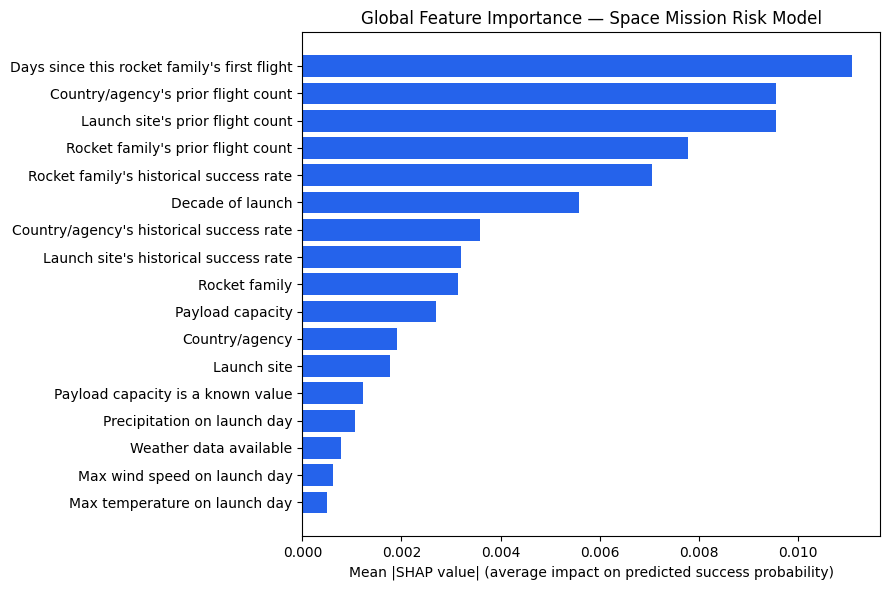

In [15]:
import os
os.makedirs("presentation", exist_ok=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance_df["label"][::-1], importance_df["mean_abs_shap"][::-1], color="#2563eb")
ax.set_xlabel("Mean |SHAP value| (average impact on predicted success probability)")
ax.set_title("Global Feature Importance — Space Mission Risk Model")
plt.tight_layout()
plt.savefig("presentation/shap_global_importance.png", dpi=150)
plt.show()

## Step 6 — Failure-factor analysis (bonus objective)

The problem statement's bonus list includes "SHAP-based decomposition of
which inputs drove historical failures." Here we isolate only the actual
historical failures and look at what the model identifies as the biggest
risk contributors specifically for those launches — a more targeted view
than the general importance ranking above.

In [11]:
failures_df = features[features["mission_success"] == 0]
print(f"Total historical failures in dataset: {len(failures_df)}")

failure_sample = failures_df.sample(min(20, len(failures_df)), random_state=42)  # reduced from 50
X_failures_raw = failure_sample[FEATURE_COLS]

category_maps = explainer._category_maps
X_failures_encoded = _encode(X_failures_raw, category_maps)

shap_values_failures = explainer(X_failures_encoded, max_evals=100)

mean_shap_failures = shap_values_failures.values.mean(axis=0)
failure_factor_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "label": [FEATURE_LABELS.get(f, f) for f in FEATURE_COLS],
    "mean_shap_on_failures": mean_shap_failures,
}).sort_values("mean_shap_on_failures")

print("Features most associated with predicted failure risk:")
print(failure_factor_df.head(8).to_string(index=False))

Total historical failures in dataset: 404


PermutationExplainer explainer: 21it [00:47,  2.98s/it]

Features most associated with predicted failure risk:
                   feature                                        label  mean_shap_on_failures
     country_prior_flights          Country/agency's prior flight count              -0.021551
          vehicle_age_days Days since this rocket family's first flight              -0.021075
country_prior_success_rate     Country/agency's historical success rate              -0.016968
        site_prior_flights             Launch site's prior flight count              -0.015687
     vehicle_prior_flights           Rocket family's prior flight count              -0.013694
vehicle_prior_success_rate      Rocket family's historical success rate              -0.008842
                    decade                             Decade of launch              -0.007238
   site_prior_success_rate        Launch site's historical success rate              -0.006071


In [16]:
from google.colab import files
import os

files_to_download = [
    "presentation/shap_global_importance.png",
]

print("Files ready to download:\n")
for f in files_to_download:
    if os.path.exists(f):
        size_kb = os.path.getsize(f) / 1024
        print(f"  {f} ({size_kb:.1f} KB)")
    else:
        print(f"  MISSING: {f}")

print("\nDownloading now...")
for f in files_to_download:
    if os.path.exists(f):
        files.download(f)

Files ready to download:

  presentation/shap_global_importance.png (118.9 KB)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary

- Validated the model's predictions behave sensibly on both a reliable and
  an unproven hypothetical vehicle before trusting SHAP output.
- Built a model-agnostic SHAP explainer compatible with our calibrated
  Random Forest pipeline.
- Confirmed per-mission explanations are directionally consistent with the
  reliability patterns found during EDA.
- Produced a global feature-importance chart (`presentation/shap_global_importance.png`)
  for the presentation deck.
- Ran a failure-focused SHAP decomposition, satisfying the bonus objective
  of explaining what specifically drives historical failure predictions.

`src/predict.py` and `src/explain.py` are now validated end-to-end and ready
to be imported directly into the Streamlit dashboard — no further changes
to the model or feature pipeline needed.

**Next:** `dashboard/app.py` — the Streamlit interface wiring together
historical analytics, the what-if simulator, and per-mission SHAP explanations.